In [1]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

In [3]:
df = pd.read_csv("/kaggle/input/datasets/buketsak/data3-nmt-analysis-n1/data3_nmt_analysis.csv")

In [4]:
# CSV cannot store lists, only strings.
# convert JSON strings to Python lists by json.loads() after reading.
model_cols = [
    "human_translations",
    "opus-tatoeba-en-tr",
    "m2m100-418M",
    "NLLB200-3.3B",
    "translategemma-4b",
    "llama3.1-IT-8B"
]

for col in model_cols:
    df[f"subject_pro_{col}"] = df[f"subject_pro_{col}"].apply(json.loads)
    df[f"pro_labels_{col}"] = df[f"pro_labels_{col}"].apply(json.loads)

In [5]:
from collections import Counter

def count_pronoun_labels(series):
    labels = []
    for lst in series:
        if isinstance(lst, list):
            labels.extend(lst)
    return Counter(labels)

In [6]:
results = {}

for col in model_cols:
    label_col = f"pro_labels_{col}"
    counts = count_pronoun_labels(df[label_col])

    results[col] = {
        "Overt (1)": counts.get("1", 0),
        "Dropped (0)": counts.get("0", 0),
        "Total": counts.get("1", 0) + counts.get("0", 0)}

In [7]:
summary_df = pd.DataFrame.from_dict(results, orient="index")
summary_df

,Overt (1),Dropped (0),Total
human_translations,208,5,213
opus-tatoeba-en-tr,154,59,213
m2m100-418M,44,169,213
NLLB200-3.3B,184,29,213
translategemma-4b,172,41,213
llama3.1-IT-8B,122,91,213


In [8]:
summary_df["Overt %"] = (summary_df["Overt (1)"] / summary_df["Total"] * 100).map("{:.2f}".format)
summary_df["Dropped %"] = (summary_df["Dropped (0)"] / summary_df["Total"] * 100).map("{:.2f}".format)

summary_df

,Overt (1),Dropped (0),Total,Overt %,Dropped %
human_translations,208,5,213,97.65,2.35
opus-tatoeba-en-tr,154,59,213,72.30,27.70
m2m100-418M,44,169,213,20.66,79.34
NLLB200-3.3B,184,29,213,86.38,13.62
translategemma-4b,172,41,213,80.75,19.25
llama3.1-IT-8B,122,91,213,57.28,42.72


Look what the models actually produced in nsubj positions.

In [9]:
def collect_overt_pronouns(series):
    pronouns = []
    for cell in series:
        for p in cell:
            if p != "-":
                pronouns.append(p)
    return Counter(pronouns)

In [10]:
results = {}

for col in model_cols:
    results[col] = collect_overt_pronouns(df[f"subject_pro_{col}"])

In [11]:
for model, counter in results.items():
    print(f"\n{model}")
    for pron, count in counter.most_common():
        print(f"  {pron}: {count}")


human_translations
  o: 81
  sen: 45
  ben: 44
  onlar: 19
  biz: 19

opus-tatoeba-en-tr
  ben: 37
  sen: 35
  o: 35
  biz: 14
  adam: 13
  kadın: 11
  onlar: 7
  kız: 1
  siz: 1

m2m100-418M
  ben: 19
  o: 7
  onlar: 7
  sen: 6
  biz: 4
  siz: 1

NLLB200-3.3B
  o: 49
  ben: 41
  sen: 34
  biz: 16
  onlar: 15
  kadın: 12
  erkek: 5
  kocası: 4
  karısı: 3
  adam: 3
  bizler: 1
  siz: 1

translategemma-4b
  o: 74
  ben: 40
  siz: 20
  onlar: 15
  biz: 15
  sen: 5
  her: 2
  diğer: 1

llama3.1-IT-8B
  o: 51
  ben: 34
  siz: 12
  onlar: 10
  biz: 10
  sen: 5


In [12]:
def pronoun_percentages(counter):
    total = sum(counter.values())
    return {k: round(v / total * 100, 2) for k, v in counter.items()}

for model, counter in results.items():
    print(f"\n{model}")
    print(pronoun_percentages(counter))


human_translations
{'sen': 21.63, 'ben': 21.15, 'o': 38.94, 'onlar': 9.13, 'biz': 9.13}

opus-tatoeba-en-tr
{'sen': 22.73, 'ben': 24.03, 'o': 22.73, 'kadın': 7.14, 'adam': 8.44, 'biz': 9.09, 'onlar': 4.55, 'kız': 0.65, 'siz': 0.65}

m2m100-418M
{'ben': 43.18, 'o': 15.91, 'sen': 13.64, 'siz': 2.27, 'onlar': 15.91, 'biz': 9.09}

NLLB200-3.3B
{'ben': 22.28, 'o': 26.63, 'sen': 18.48, 'kadın': 6.52, 'erkek': 2.72, 'karısı': 1.63, 'kocası': 2.17, 'biz': 8.7, 'onlar': 8.15, 'adam': 1.63, 'bizler': 0.54, 'siz': 0.54}

translategemma-4b
{'ben': 23.26, 'siz': 11.63, 'sen': 2.91, 'o': 43.02, 'onlar': 8.72, 'biz': 8.72, 'her': 1.16, 'diğer': 0.58}

llama3.1-IT-8B
{'ben': 27.87, 'sen': 4.1, 'o': 41.8, 'siz': 9.84, 'onlar': 8.2, 'biz': 8.2}


In [13]:
counts = {}
all_pronouns = set()

# counts for each model and collect all pronouns
for col in model_cols:
    pronouns = []
    for cell in df[f"subject_pro_{col}"]:
        for p in cell:
            if p != "-":  # ignore dropped subjects
                pronouns.append(p)
    counts[col] = Counter(pronouns)
    all_pronouns.update(counts[col].keys())

#create a DataFrame from the counts
df_counts = pd.DataFrame({col: counts[col] for col in model_cols}).fillna(0).astype(int)

# sum across models to sort by total frequency
df_counts["total"] = df_counts.sum(axis=1)

df_counts = df_counts.sort_values(by="total", ascending=False).drop(columns="total")

df_counts

,human_translations,opus-tatoeba-en-tr,m2m100-418M,NLLB200-3.3B,translategemma-4b,llama3.1-IT-8B
o,81,35,7,49,74,51
ben,44,37,19,41,40,34
sen,45,35,6,34,5,5
biz,19,14,4,16,15,10
onlar,19,7,7,15,15,10
siz,0,1,1,1,20,12
kadın,0,11,0,12,0,0
adam,0,13,0,3,0,0
erkek,0,0,0,5,0,0
kocası,0,0,0,4,0,0


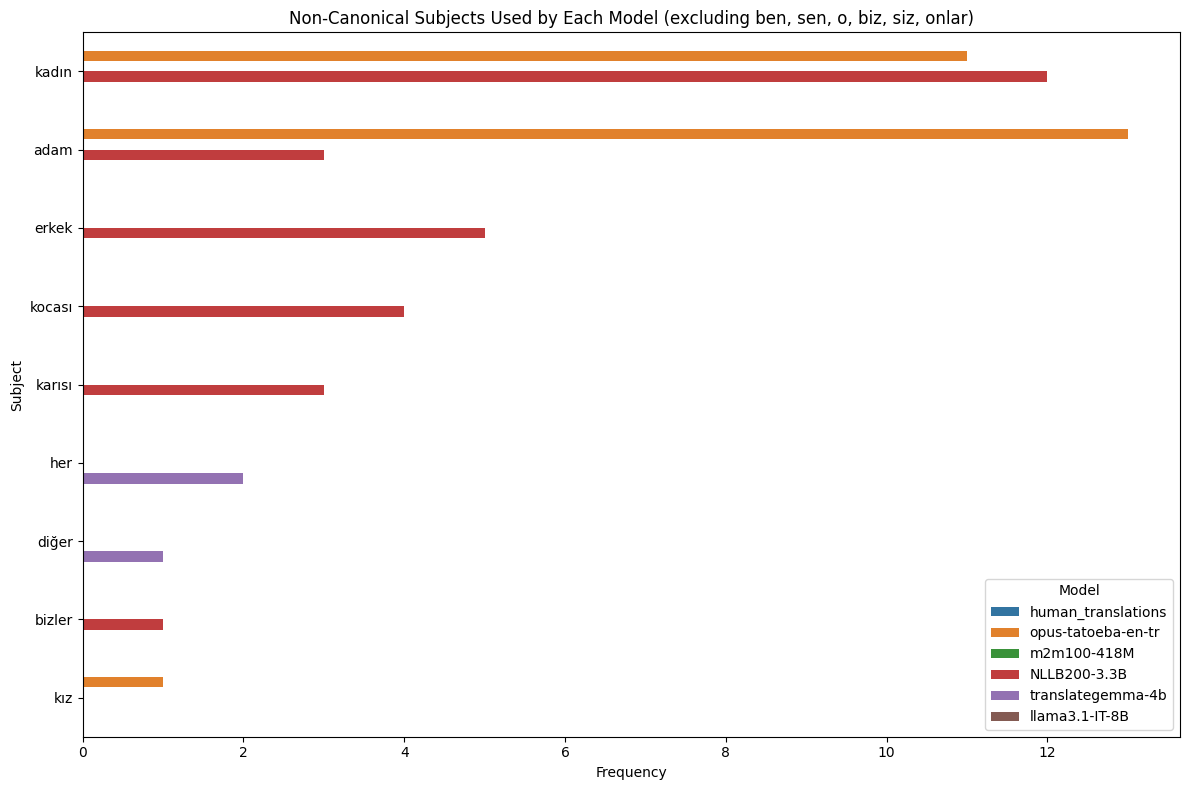

In [14]:
# canonical pronouns to exclude
exclude_pronouns = {"ben", "sen", "o", "biz", "siz", "onlar"}

#filter df_counts
other_counts = df_counts[~df_counts.index.isin(exclude_pronouns)]

#convert to long format for seaborn
plot_df = other_counts.reset_index().melt(id_vars="index", 
                                          var_name="model", 
                                          value_name="count")
plot_df = plot_df.rename(columns={"index": "subject"})
# order subjects by total frequency
subject_order = (
    plot_df.groupby("subject")["count"]
    .sum()
    .sort_values(ascending=False)
    .index
)
# Plot
plt.figure(figsize=(12,8))
sns.barplot(data=plot_df, y="subject", x="count", hue="model", order=subject_order)
plt.title("Non-Canonical Subjects Used by Each Model (excluding ben, sen, o, biz, siz, onlar)")
plt.xlabel("Frequency")
plt.ylabel("Subject")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

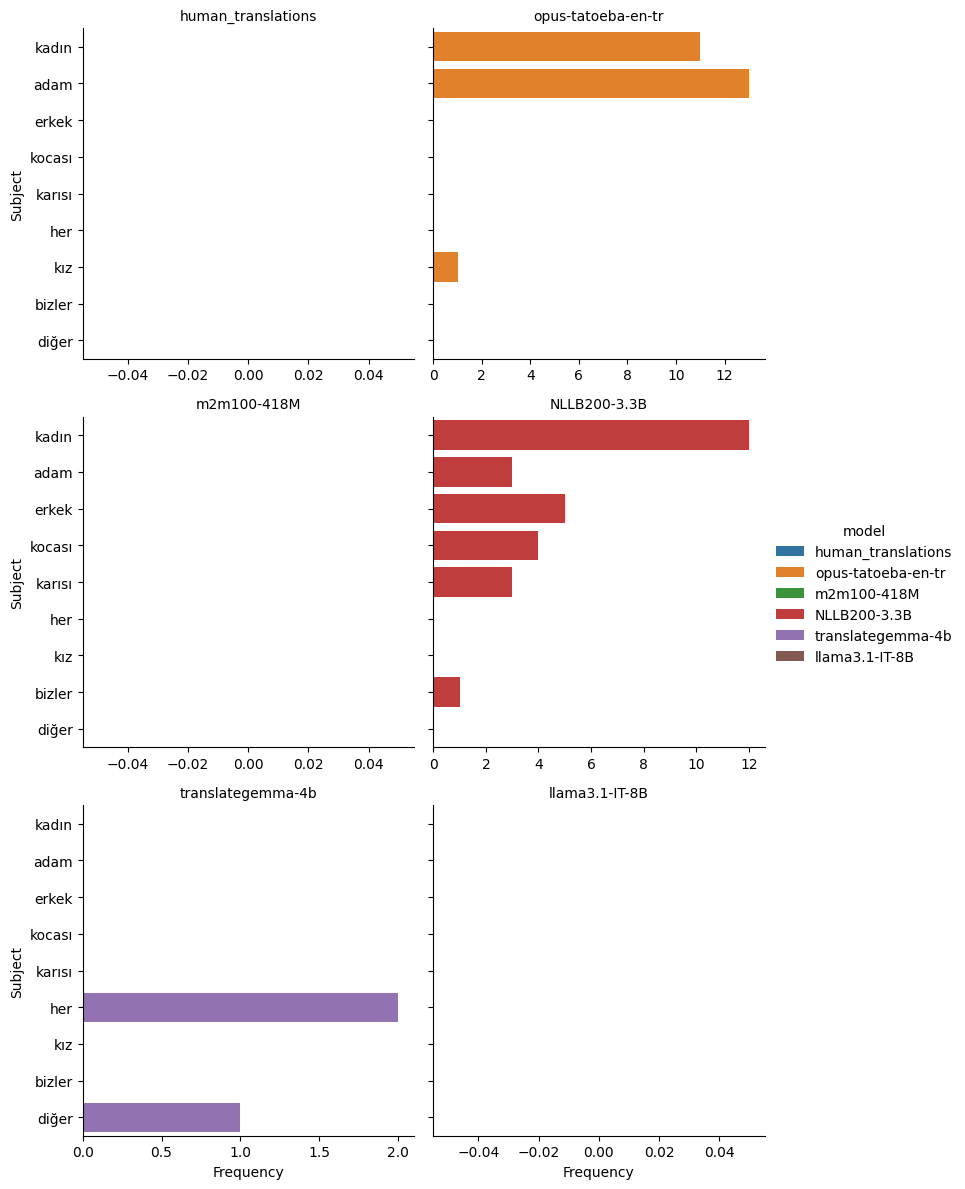

In [15]:
g = sns.catplot(
    data=plot_df, 
    y="subject", 
    x="count", 
    hue="model", 
    kind="bar",
    col="model",
    col_wrap=2,
    height=4,
    sharex=False
)
g.set_titles("{col_name}")
g.set_axis_labels("Frequency", "Subject")
plt.show()

In [16]:
#only with pronouns
PRONOUNS = ["ben", "sen", "o", "biz", "siz", "onlar"]

counts = {}
all_pronouns = set()

# gather counts for each model and collect all pronouns
for col in model_cols:
    pronouns = []
    for cell in df[f"subject_pro_{col}"]:
        for p in cell:
            if p != "-":  # ignore dropped subjects
                pronouns.append(p)
    counts[col] = Counter(pronouns)
    all_pronouns.update(counts[col].keys())


# convert to dataframe
df_counts = pd.DataFrame(counts).fillna(0).astype(int)
df_counts = df_counts.reindex(PRONOUNS)
df_counts

,human_translations,opus-tatoeba-en-tr,m2m100-418M,NLLB200-3.3B,translategemma-4b,llama3.1-IT-8B
ben,44,37,19,41,40,34
sen,45,35,6,34,5,5
o,81,35,7,49,74,51
biz,19,14,4,16,15,10
siz,0,1,1,1,20,12
onlar,19,7,7,15,15,10


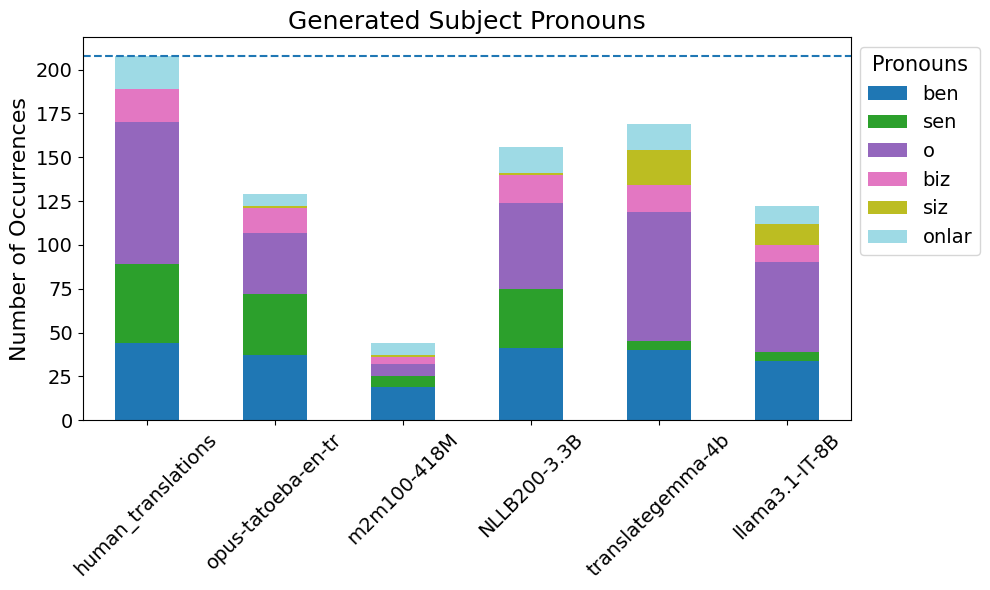

In [17]:
# Stacked bar plot, get the axes object
ax = df_counts.T.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')

# add horizontal line (to show the gap clear)
ax.axhline(y=208, linestyle="--")

# Titles and labels
plt.title("Generated Subject Pronouns", fontsize=18)
plt.ylabel("Number of Occurrences", fontsize=16)

# Tick labels
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

# Legend
plt.legend(title="Pronouns", 
           bbox_to_anchor=(1.00, 1), 
           loc='upper left',
           fontsize=14,
           title_fontsize=15)
plt.tight_layout()
plt.savefig("comparison.png", dpi=300, bbox_inches="tight")
plt.show()

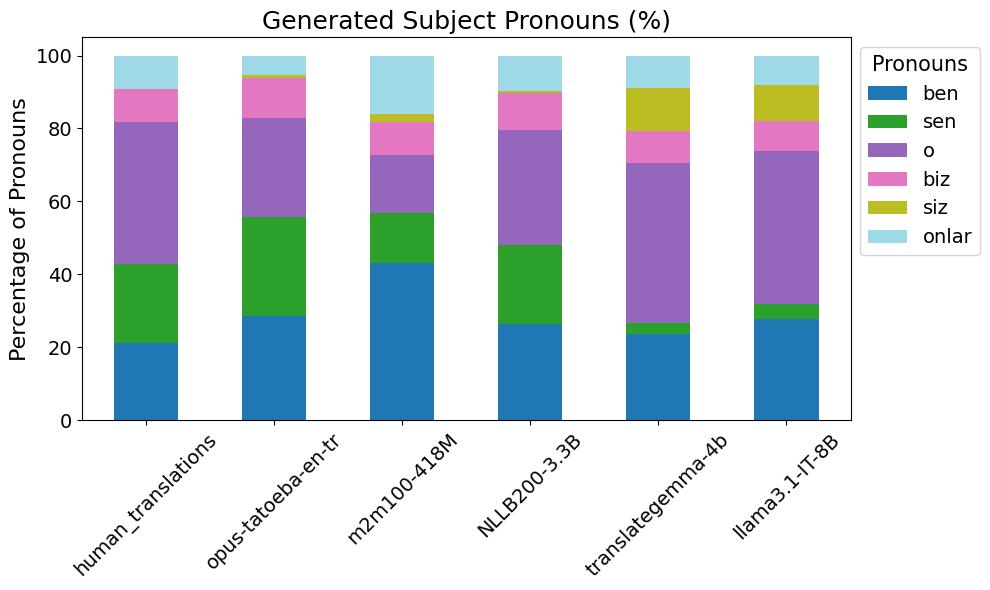

In [18]:
df_counts_pct = df_counts.div(df_counts.sum(axis=0), axis=1) * 100

# Stacked bar plot, get axes object

ax = df_counts_pct.T.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')

# Titles and labels
plt.title("Generated Subject Pronouns (%)", fontsize=18)
plt.ylabel("Percentage of Pronouns", fontsize=16)

# Tick labels
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

# Legend
plt.legend(title="Pronouns",
           bbox_to_anchor=(1.00, 1),
           loc='upper left',
           fontsize=14,
           title_fontsize=15)

plt.tight_layout()

# Save before show if needed
plt.savefig("comparison_rate.png", dpi=300, bbox_inches="tight")

plt.show()

To do it in R -- long format

In [19]:
def long_df(df, model_cols):
    long_rows = []

    for model in model_cols:
        subj_col = f"subject_pro_{model}"
        label_col = f"pro_labels_{model}"

        for idx, (subjects, labels) in enumerate(zip(df[subj_col], df[label_col])):
            if not (isinstance(subjects, list) and isinstance(labels, list)):
                continue

            for i, label in enumerate(labels):
                subj = subjects[i] if i < len(subjects) else None

                long_rows.append({
                    "model": model,
                    "sentence_id": df.loc[idx, "sentence_id"],
                    "pronoun": subj if subj != "-" else None,
                    "subject_type": "overt" if label == "1" else "dropped"
                })

    return pd.DataFrame(long_rows)

long_df3 = long_df(df, model_cols)
long_df3.to_csv("long_df3_subjects.csv", index=False)
long_df3.head()

,model,sentence_id,pronoun,subject_type
0,human_translations,1,sen,overt
1,human_translations,1,ben,overt
2,human_translations,2,sen,overt
3,human_translations,2,ben,overt
4,human_translations,3,sen,overt


In [20]:
PRONOUNS = {"ben", "sen", "o", "biz", "siz", "onlar"}

rows = []

for model in model_cols:
    if model == "human_translations":
        continue

    for idx, (human_list, model_list) in enumerate(
        zip(df["subject_pro_human_translations"], df[f"subject_pro_{model}"])
    ):
        if not (isinstance(human_list, list) and isinstance(model_list, list)):
            continue

        for i in range(min(len(human_list), len(model_list))):
            gold = human_list[i]
            pred = model_list[i]

            # only evaluate overt pronouns
            if gold in PRONOUNS and pred in PRONOUNS:
                rows.append({
                    "model": model,
                    "gold": gold,
                    "pred": pred
                                    })

eval_df = pd.DataFrame(rows)
eval_df.head()

,model,gold,pred
0,opus-tatoeba-en-tr,sen,sen
1,opus-tatoeba-en-tr,ben,ben
2,opus-tatoeba-en-tr,sen,sen
3,opus-tatoeba-en-tr,ben,ben
4,opus-tatoeba-en-tr,o,o


In [21]:
#pronouns
PRONOUNS = {"ben", "sen", "o", "biz", "siz", "onlar"}

# Build evaluation dataframe
rows = []
for model in model_cols:
    if model == "human_translations":
        continue

    for idx, (gold_list, pred_list) in enumerate(
        zip(df["subject_pro_human_translations"], df[f"subject_pro_{model}"])
    ):
        if not (isinstance(gold_list, list) and isinstance(pred_list, list)):
            continue

        for i in range(min(len(gold_list), len(pred_list))):
            gold = gold_list[i] if gold_list[i] is not None else "-"   # mark nulls
            pred = pred_list[i] if pred_list[i] is not None else "-"

            rows.append({
                "model": model,
                "gold": gold,
                "pred": pred
            })

eval_df = pd.DataFrame(rows)

# Function to convert token to behavior
def pronoun_behavior(x):
    if x == "-":
        return "Dropped"
    else:
        return "Overt"  # includes pronouns and all other words

# Overt vs Dropped evaluation
print(" Overt vs Dropped Evaluation")

for model in eval_df["model"].unique():
    sub = eval_df[eval_df["model"] == model]

    gold_behavior = sub["gold"].apply(pronoun_behavior)
    pred_behavior = sub["pred"].apply(pronoun_behavior)

    print(f"\n{model}")
    print("Accuracy (Overt vs Dropped):", accuracy_score(gold_behavior, pred_behavior))
    print(classification_report(
        gold_behavior,
        pred_behavior,
        labels=["Overt", "Dropped"],
        zero_division=0 ))

 Overt vs Dropped Evaluation

opus-tatoeba-en-tr
Accuracy (Overt vs Dropped): 0.7464788732394366
              precision    recall  f1-score   support

       Overt       1.00      0.74      0.85       208
     Dropped       0.08      1.00      0.16         5

    accuracy                           0.75       213
   macro avg       0.54      0.87      0.50       213
weighted avg       0.98      0.75      0.83       213


m2m100-418M
Accuracy (Overt vs Dropped): 0.2300469483568075
              precision    recall  f1-score   support

       Overt       1.00      0.21      0.35       208
     Dropped       0.03      1.00      0.06         5

    accuracy                           0.23       213
   macro avg       0.51      0.61      0.20       213
weighted avg       0.98      0.23      0.34       213


NLLB200-3.3B
Accuracy (Overt vs Dropped): 0.8873239436619719
              precision    recall  f1-score   support

       Overt       1.00      0.88      0.94       208
     Dropped     

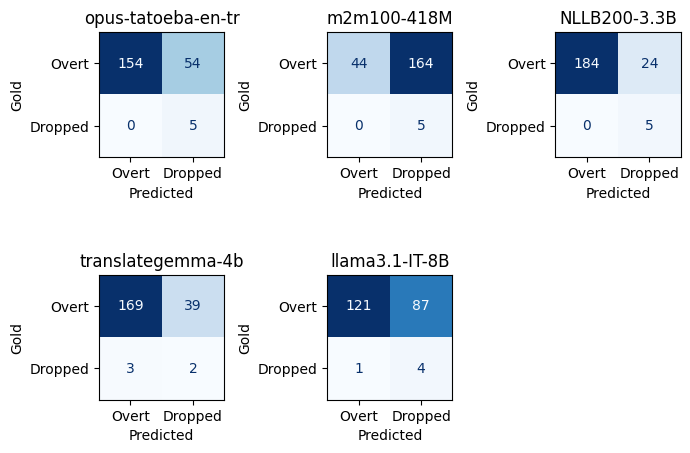

In [22]:
# confusion matrix plotting
models = eval_df["model"].unique()
n = len(models)

#  grid size
cols = 3
rows = 3

fig, axes = plt.subplots(rows, cols, figsize=(7, 7))
axes = axes.flatten()

for ax, model in zip(axes, models):
    sub = eval_df[eval_df["model"] == model]

    gold_behavior = sub["gold"].apply(pronoun_behavior)
    pred_behavior = sub["pred"].apply(pronoun_behavior)

    cm = confusion_matrix(
        gold_behavior,
        pred_behavior,
        labels=["Overt", "Dropped"]
    )
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Overt", "Dropped"]
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.set_title(model)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Gold")

# Remove empty subplots
for i in range(len(models), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [23]:
# pronoun-level evaluation (only overt pronouns)
print("\nPronoun-level Accuracy")

overt_df = eval_df[eval_df["gold"] != "-"]  # only consider overt gold pronouns

for model in overt_df["model"].unique():
    sub = overt_df[overt_df["model"] == model]

    print(f"\n {model}")
    print("Accuracy (Pronouns only):", accuracy_score(sub["gold"], sub["pred"]))
    print(classification_report(
        sub["gold"],
        sub["pred"],
        labels=sorted(PRONOUNS),
        zero_division=0
    ))


Pronoun-level Accuracy

 opus-tatoeba-en-tr
Accuracy (Pronouns only): 0.6153846153846154
              precision    recall  f1-score   support

         ben       1.00      0.84      0.91        44
         biz       1.00      0.74      0.85        19
           o       1.00      0.43      0.60        81
       onlar       1.00      0.37      0.54        19
         sen       1.00      0.78      0.88        45
         siz       0.00      0.00      0.00         0

   micro avg       0.99      0.62      0.76       208
   macro avg       0.83      0.53      0.63       208
weighted avg       1.00      0.62      0.74       208


 m2m100-418M
Accuracy (Pronouns only): 0.20673076923076922
              precision    recall  f1-score   support

         ben       1.00      0.43      0.60        44
         biz       1.00      0.21      0.35        19
           o       1.00      0.09      0.16        81
       onlar       1.00      0.37      0.54        19
         sen       1.00      0.13   

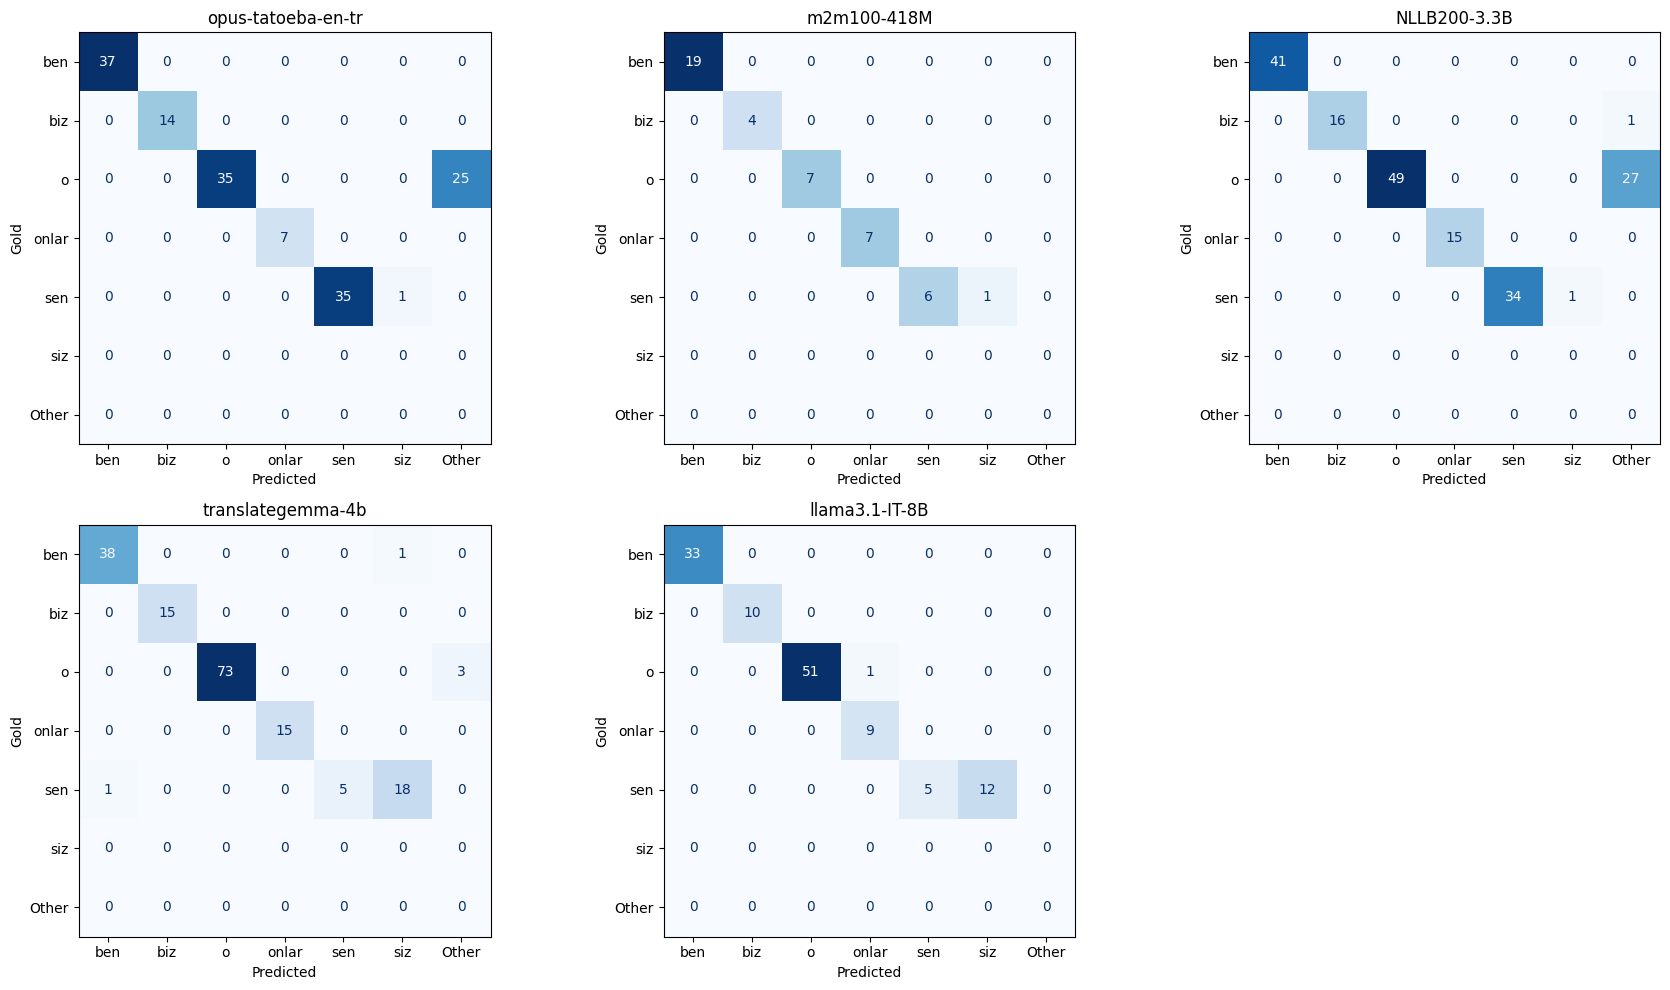

In [26]:
rows = []
for model in model_cols:
    if model == "human_translations":
        continue

    for gold_list, pred_list in zip(df["subject_pro_human_translations"], df[f"subject_pro_{model}"]):
        if not (isinstance(gold_list, list) and isinstance(pred_list, list)):
            continue

        for i in range(min(len(gold_list), len(pred_list))):
            gold = gold_list[i] if gold_list[i] is not None else "-"
            pred = pred_list[i] if pred_list[i] is not None else "-"

            rows.append({
                "model": model,
                "gold": gold,
                "pred": pred
            })

eval_df = pd.DataFrame(rows)

# each pronoun, other (exclude dropped from visualization)
def token_category(x):
    if x == "-":
        return None  # exclude dropped from confusion matrix
    elif x in PRONOUNS:
        return x  # keep pronoun as label
    else:
        return "Other"

# Confusion matrix plotting for all models (overt subjects only)
models = eval_df["model"].unique()
n = len(models)
cols = 3
rows = 2
fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
axes = axes.flatten()

# Sorted pronouns + other
labels = sorted(PRONOUNS) + ["Other"]

for ax, model in zip(axes, models):
    sub = eval_df[eval_df["model"] == model]

    gold_cat = sub["gold"].apply(token_category)
    pred_cat = sub["pred"].apply(token_category)

    # keep only overt subjects (exclude dropped)
    mask = gold_cat.notna() & pred_cat.notna()
    gold_cat = gold_cat[mask]
    pred_cat = pred_cat[mask]

    cm = confusion_matrix(
        gold_cat,
        pred_cat,
        labels=labels)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d")

    ax.set_title(model)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Gold")

# Remove empty subplots
for i in range(len(models), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()